In [4]:
using Pkg
Pkg.activate("/Users/jercheal/.julia/environments/v1.11/transfer_matrix_poly/")
using Plots
using ColorSchemes
using NLsolve
using BenchmarkTools
#using Polylogarithms #removed due to conflict with LsqFit package
using LinearAlgebra
using CSV
using DataFrames
#using NonlinearSolve
#using LsqFit

include("wynn.jl")
include("transfer_matrix.jl")

function solve_eom_VS_VT(j0::Float64, jf::Float64, Λ::Float64, γ::Float64, VT::Int64, VS, k_guess::Float64, iterations::Int64=10000, xtol::Float64=1e-10, ftol::Float64=1e-10)
    discr_sols = nlsolve(eom_nslice(j0 / VS^2, jf / VS^2, Λ, γ, VT), generate_initguess(j0 / VS^2, jf / VS^2, k_guess, Λ, γ, VT), iterations=iterations, xtol=xtol, ftol=ftol).zero
    js = VS^2 .* vcat([j0 / VS^2], discr_sols[2:2:end], [jf / VS^2])
    ks = discr_sols[1:2:end]
    Hs = [height(js[n] / VS^2, js[n+1] / VS^2, ks[n]) for n in 1:VT]
    prop_time = vcat([0.0], accumulate(+, Hs))
    return (js, ks, Hs, prop_time)
end

function eom_for_scale(j0, j1, Λ)
    T0 = log(sqrt(j1)/sqrt(j0)) * sqrt(3 / Λ)


    function eom_scale(c)
        k_cont = k_from_height(j0 / c[1]^2, j1 / c[1]^2, T0)
        return dS_IIIdk(j0 / c[1]^2, j1 / c[1]^2, k_cont, Λ)
    end
    return eom_scale
end

  Activating project at `~/.julia/environments/v1.11/transfer_matrix_poly`


eom_for_scale (generic function with 1 method)

In [5]:
using LaTeXStrings
plot_font = "Computer Modern"
default(fontfamily=plot_font,
        linewidth=2, framestyle=:box, label=nothing, grid=false)
scalefontsizes(1.0)

# Path integral for continuum action

When computing transition amplitudes with the transfer matrix, we get the transition for all the boundary states $j_{\mathrm{in}},j_{\mathrm{fi}}$. However, only for a single pair of $j_{\mathrm{in}}, j_{\mathrm{fi}}$, the $\kappa$ can be chosen such that the action captures the continuum.\
Thus, the path integral naturally contains a superposition of actions for which only a single one is the continuum action. When this one dominates though, then the entire transition should be continuous. 

In [5]:
# Adjusting the trans_mat function to the perfect action application

function trans_mat_perfect(O::Function, a_max::Float64, γ::Float64, Λ::Float64, V::Int64, kappa::Float64, rtol::Float64=1e-10, ref_sl::Float64=1.0, ref_tl::Float64=1.0, α::Float64=2.5)
    """
    For the moment without built-in refinement
    """
    N = Int(2 * a_max / γ) # maximum index of mat
    mat = zeros(ComplexF64, N, N)
    k_spec = ref_tl * 0.5
    for i0 in 1:N
        for i1 in 1:i0
            kmax = max(100 * k_spec, 3 * linear_k_sol(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, Λ))
            kvals = k_spec:k_spec:kmax
            amplitudes = [O(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ_toy(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k, α) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
            mat_element = wynn(accumulate(+, amplitudes)[end - 50:end], rtol)[1]
            mat[i0, i1] = mat_element
            mat[i1, i0] = mat_element
        end
    end
    return mat
end

trans_mat_perfect (generic function with 5 methods)

In [139]:
# Computing kappa for the desired transition

j0 = 30.0
j1 = 60.0
Λ = 0.1
γ = 1.0
T0 = log(sqrt(j1)/sqrt(j0)) * sqrt(3 / Λ)

kappa = nlsolve(eom_for_scale(j0, j1, Λ), [3.1525880183404897]).zero[1]
print("The proper time is T0 = ", log(sqrt(j1)/sqrt(j0)) * sqrt(3 / Λ), "\n")
print("The solution for kappa is: ", kappa, "\n")

The proper time is T0 = 1.8982617323189424
The solution for kappa is: 3.8611160065971832


In [122]:
# One time step

V = 1
a_max = 80.0
Tk = trans_mat_perfect(trap, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)
T1 = trans_mat_perfect(id, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)
k_evals = Tk ./ T1
k_ev = k_evals[60, 120]
j_evs_1 = [30.0, 60.0]
Hs = [height(j0 / kappa^2, j1 / kappa^2, real(k_ev))]
prop_times_1 = vcat([0.0], accumulate(+, Hs))

2-element Vector{Float64}:
 0.0
 1.8984751190037688

In [101]:
# By hand computation

amplitude1 = [μ_toy(30.0, 60.0, k, 2.5) * exp(im * kappa^3 * S_III(30 / kappa^2, 60 / kappa^2, k, 0.1)) for k in 0.1:0.01:5]
amplitudek = [trap(30.0 / kappa^2, 60.0 / kappa^2, k) * μ_toy(30.0, 60.0, k, 2.5) * exp(im * kappa^3 * S_III(30 / kappa^2, 60 / kappa^2, k, 0.1)) for k in 0.1:0.01:5]
Z1 = wynn(accumulate(+, amplitude1)[end-50:end], 1e-10)[1]
Zk = wynn(accumulate(+, amplitudek)[end-50:end], 1e-10)[1]
ev = Zk / Z1
height(j0 / kappa^2, j1 / kappa^2, real(ev))

1.8857818649157927

In [89]:
height(j0 / kappa^2, j1 / kappa^2, 3.171678582758944)

1.898261732331876

In [117]:
solve_eom_VS_VT(j0, j1, Λ, γ, 4, kappa, 3.17)

([30.0, 36.52365416868783, 43.696074949871445, 51.52039811508457, 60.0], [0.8022533419685954, 0.8031989220294613, 0.8042199392805991, 0.805313318482574], [0.5476515164351896, 0.5010397999379801, 0.4622500006023676, 0.4295020088933631], [0.0, 0.5476515164351896, 1.0486913163731697, 1.5109413169755372, 1.9404433258689004])

In [147]:
# Two time steps

V = 2
N = 160
jmat = zeros(Float64, N, N)
for n in 1:N
    jmat[n,n] = n / (2 * (kappa * V)^2)
end

Tk = trans_mat_perfect(trap, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)
T1 = trans_mat_perfect(id, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)

Z = T1^2
Zk = [Tk * T1, T1 * Tk]
Zj = [jmat * T1^2, T1 * jmat * T1, T1^2 * jmat]

k_evs_2 = [Zk[1][60,120] / Z[60,120], Zk[2][60,120] / Z[60,120]]
j_evs_2 = (kappa * V)^2 .* [Zj[1][60,120] / Z[60,120], Zj[2][60,120] / Z[60,120], Zj[3][60,120] / Z[60,120]]
Hs_2 = [height(real(j_evs_2)[n] / (kappa * V)^2, real(j_evs_2)[n+1] / (kappa * V)^2, real(k_evs_2)[n]) for n in 1:V]
prop_times_2 = vcat([0.0], accumulate(+, Hs_2))

3-element Vector{Float64}:
 0.0
 1.0237281189545624
 1.892189020638415

In [127]:
# Three time steps

V = 3
N = 160
jmat = zeros(Float64, N, N)
for n in 1:N
    jmat[n,n] = n / (2 * (kappa * V)^2)
end

Tk = trans_mat_perfect(trap, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)
T1 = trans_mat_perfect(id, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)

Z = T1^3
Zk = [Tk * T1^2, T1 * Tk * T1, T1^2 * Tk]
Zj = [jmat * T1^3, T1 * jmat * T1^2, T1^2 * jmat * T1, T1^3 * jmat]

k_evs_3 = [Zk[n][60,120] / Z[60,120] for n in 1:V]
j_evs_3 = (kappa * V)^2 .* [Zj[n][60,120] / Z[60,120] for n in 1:(V+1)]
Hs_3 = [height(real(j_evs_3)[n] / (kappa * V)^2, real(j_evs_3)[n+1] / (kappa * V)^2, real(k_evs_3)[n]) for n in 1:V]
prop_times_3 = vcat([0.0], accumulate(+, Hs_3))

4-element Vector{Float64}:
 0.0
 0.693166220397055
 1.3234187236787749
 1.8906098167740029

In [163]:
# Four time steps

V = 4
N = 160
jmat = zeros(Float64, N, N)
for n in 1:N
    jmat[n,n] = n / (2 * (kappa * V)^2)
end

Tk = trans_mat_perfect(trap, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.009)
T1 = trans_mat_perfect(id, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.009)

Z = T1^4
Zk = [Tk * T1^3, T1 * Tk * T1^2, T1^2 * Tk * T1, T1^3 * Tk]
Zj = [jmat * T1^4, T1 * jmat * T1^3, T1^2 * jmat * T1^2, T1^3 * jmat * T1,  T1^4 * jmat]

k_evs_4 = [Zk[n][60,120] / Z[60,120] for n in 1:V]
j_evs_4 = (kappa * V)^2 .* [Zj[n][60,120] / Z[60,120] for n in 1:(V+1)]
Hs_4 = [height(real(j_evs_4)[n] / (kappa * V)^2, real(j_evs_4)[n+1] / (kappa * V)^2, real(k_evs_4)[n]) for n in 1:V]
prop_times_4 = vcat([0.0], accumulate(+, Hs_4))

5-element Vector{Float64}:
 0.0
 0.5161270443593565
 1.0179217088943906
 1.4879091402365683
 1.9123597050913297

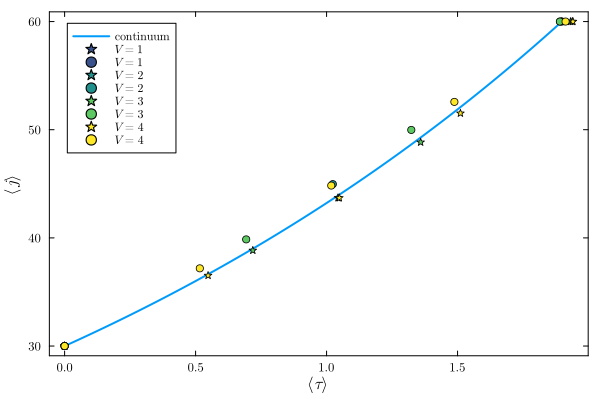

In [164]:
plt = plot(range(0, T0, 1000), [j_evol_class_cont(30.0, 60.0, t, Λ) for t in range(0, T0, 1000)], 
xlabel=L"\langle \tau\rangle", 
ylabel=L"\langle j\rangle",
label=L"\mathrm{continuum}")

js, ks, Hs, prop_ts = solve_eom_VS_VT(j0, j1, Λ, γ, 1, kappa, 3.0)
scatter!(prop_ts, js, label=L"V = 1", color=get(ColorSchemes.viridis, 1/4), markershape=:star5)
scatter!(prop_times_1, real(j_evs_1), label=L"V = 1", color=get(ColorSchemes.viridis, 1/4))
js, ks, Hs, prop_ts = solve_eom_VS_VT(j0, j1, Λ, γ, 2, kappa, 3.0)
scatter!(prop_ts, js, label=L"V = 2", color=get(ColorSchemes.viridis, 2/4), markershape=:star5)
scatter!(prop_times_2, real(j_evs_2), label=L"V = 2", color=get(ColorSchemes.viridis, 2/4))
js, ks, Hs, prop_ts = solve_eom_VS_VT(j0, j1, Λ, γ, 3, kappa, 3.0)
scatter!(prop_ts, js, label=L"V = 3", color=get(ColorSchemes.viridis, 3/4), markershape=:star5)
scatter!(prop_times_3, real(j_evs_3), label=L"V = 3", color=get(ColorSchemes.viridis, 3/4))
js, ks, Hs, prop_ts = solve_eom_VS_VT(j0, j1, Λ, γ, 4, kappa, 3.0)
scatter!(prop_ts, js, label=L"V = 4", color=get(ColorSchemes.viridis, 4/4), markershape=:star5)
scatter!(prop_times_4, real(j_evs_4), label=L"V = 4", color=get(ColorSchemes.viridis, 4/4))
display(plt)

# Finding source of discrepancy

To do so, let's consider for simplicity the $V=2$ case.

In [14]:
j0 = 30.0
j1 = 60.0
Λ = 0.1
γ = 1.0
T0 = log(sqrt(j1)/sqrt(j0)) * sqrt(3 / Λ)
kappa = nlsolve(eom_for_scale(j0, j1, Λ), [3.1525880183404897]).zero[1]
j_cl, k_cl, H_cl, prop_time_cl = solve_eom_VS_VT(j0, j1, Λ, γ, 2, kappa, 3.17)

V = 2
N = 160
jmat = zeros(Float64, N, N)
for n in 1:N
    jmat[n,n] = n / (2 * (kappa * V)^2)
end

a_max = 80.0
Tk = trans_mat_perfect(trap, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)
T1 = trans_mat_perfect(id, a_max, γ, Λ, V, kappa, 1e-10, 1.0, 0.01)

Z = T1^2
Zk = [Tk * T1, T1 * Tk]
Zj = [jmat * T1^2, T1 * jmat * T1, T1^2 * jmat];

In [32]:
j_cl[2]

43.70314113888462

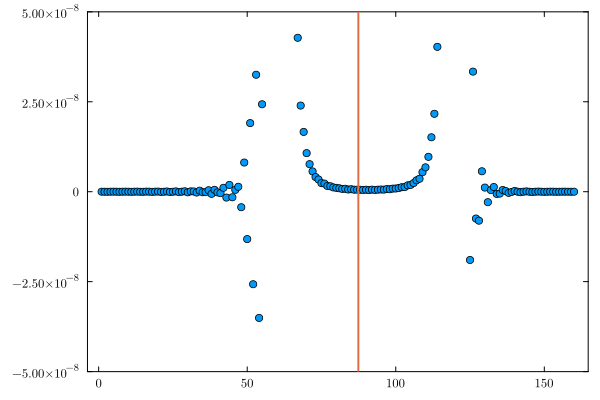

In [29]:
scatter(1:160, real([T1[60,j1] * T1[j1,120] for j1 in 1:160]), ylims=(-5e-8, 5e-8))
vline!([87.40628227776924])

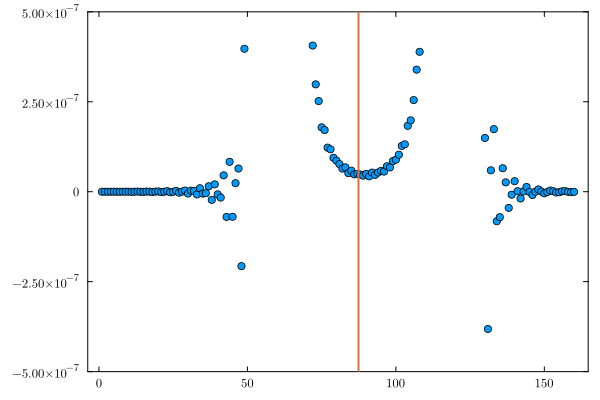

In [31]:
scatter(1:160, real([T1[60,j1] * j1 * T1[j1,120] for j1 in 1:160]), ylims=(-5e-7, 5e-7))
vline!([87.40628227776924])

In [35]:
(kappa * V)^2 .* Zj[2][60,120]/Z[60,120]

44.969687928839235 - 0.9531390167423354im

The contribution of the part of the transfer matrix that carries information on the semi-classical solution is strongly suppressed. Instead, the two contributions of $j_0$ and $j_2$ dominate. Is then $j_1$ just the arithmetic mean of $j_0$ and $j_2$? It looks a bit like this at the moment.

In [36]:
Z[60,120]

-6.544118662889554 + 87.78431960665526im

In [39]:
T1[60,60]*T1[60,120] + T1[60,120]*T1[120,120]

-6.544158692342585 + 87.78426920280788im

The partition function can be extremely well approximated by just the two diagonal contributions. And since the diagonal components have the same magnitude and only different phase, the expectation value of $j$ can actually be approximated as the arithmetic mean. This holds for all the expectation values and is a big problem as it will give a linear behavior.

## Can the measure help us?

In [3]:
function trans_mat_perfect(μ::Function, O::Function, a_max::Float64, γ::Float64, Λ::Float64, V::Int64, kappa::Float64, rtol::Float64=1e-10, ref_sl::Float64=1.0, ref_tl::Float64=1.0)
    N = Int(2 * a_max / (γ * ref_sl)) # maximum index of mat
    mat = zeros(ComplexF64, N, N)
    k_spec = ref_tl * 0.5
    for i0 in 1:N
        for i1 in 1:i0
            kmax = max(100 * k_spec, 3 * linear_k_sol(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, Λ))
            kvals = k_spec:k_spec:kmax
            amplitudes = [O(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
            mat_element = wynn(accumulate(+, amplitudes)[end - 50:end], rtol)[1]
            mat[i0, i1] = mat_element
            mat[i1, i0] = mat_element
        end
    end
    return mat
end

trans_mat_perfect (generic function with 4 methods)

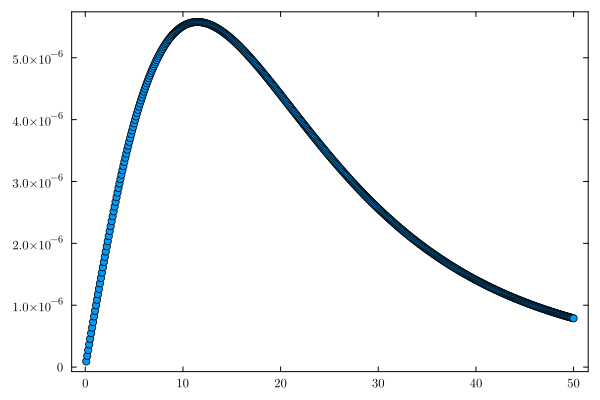

In [45]:
function mu_test(a, b)
    return (j0, j1, k) -> (k * j0 * j1)   / (((j0 - j1)^2 + 8 * k^2)^(a) * ((j0 + j1)^2 + 8 * k^2)^(b))
end

scatter(0.1:0.1:50.0 ,[mu_test(0.5, 2.0)(30.0, 60.0, k) for k in 0.1:0.1:50.0])

Checking the changes in the measure don't mess up the 1-step $k$ expectation value

In [171]:
T1 = trans_mat_perfect(id, id, a_max, γ, Λ, 1, kappa, 1e-10, 1.0, 0.01);
Tk = trans_mat_perfect(id, trap, a_max, γ, Λ, 1, kappa, 1e-10, 1.0, 0.01);
Tk[60, 120]/T1[60, 120]

3.1486633731481004 - 0.04924684611688725im

Looking at the 2-step transfer matrix

In [161]:
ref_sl = 0.1
n0 = Int(2 * 30.0 / (γ * ref_sl))
n1 = Int(2 * 60.0 / (γ * ref_sl))
N = Int(2 * 80.0 / ref_sl)

jmat = zeros(Float64, N, N)
for n in 1:N
    jmat[n,n] = n / (2 * (kappa * V)^2)
end

T1 = trans_mat_perfect(mu_test(0.5, 2.0), id, a_max, γ, Λ, 2, kappa, 1e-10, ref_sl, 0.01);
Tk = trans_mat_perfect(mu_test(0.5, 2.0), trap, a_max, γ, Λ, 2, kappa, 1e-10, ref_sl, 0.01);
Z = T1^2
(kappa * V)^2 * (T1 * jmat * T1)[n0, n1] / Z[n0, n1]

413.83316874046494 + 7.510287526867834im

In [166]:
jmat = zeros(Float64, N, N)
for n in 1:N
    jmat[n,n] = n * ref_sl / (2  *  (kappa * V)^2)
end
(kappa * V)^2 * (T1 * jmat * T1)[n0, n1] / Z[n0, n1]

41.38331687404649 + 0.7510287526867906im

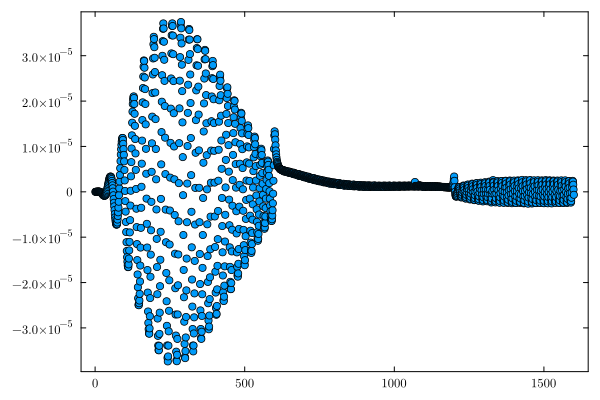

In [163]:
scatter(1:1600, real([T1[600,j1] * j1 * T1[j1,1200] for j1 in 1:1600]))

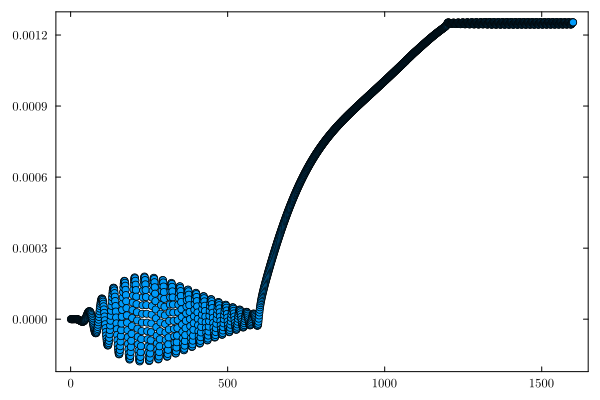

In [164]:
scatter(real(accumulate(+, [T1[600,j1] * j1 * T1[j1,1200] for j1 in 1:1600])))

Increasing $a_{\mathrm{max}}$ or refining the spacelike spectrum for better resolution?

- Increasing $a_{\mathrm{max}}$ did not help substantially.

In [153]:
a_max = 80.0
T1 = trans_mat_perfect(mu_test(0.5, 2.0), id, a_max, γ, Λ, 2, kappa, 1e-10, 1.0, 0.01);
Tk = trans_mat_perfect(mu_test(0.5, 2.0), trap, a_max, γ, Λ, 2, kappa, 1e-10, 1.0, 0.01);
Z = T1^2
jmat = zeros(Float64, 160, 160)
for n in 1:N
    jmat[n,n] = n / (2 * (kappa * V)^2)
end
(kappa * V)^2 * (T1 * jmat * T1)[60,120] / Z[60,120]

41.08239640692046 + 0.777972389404029im

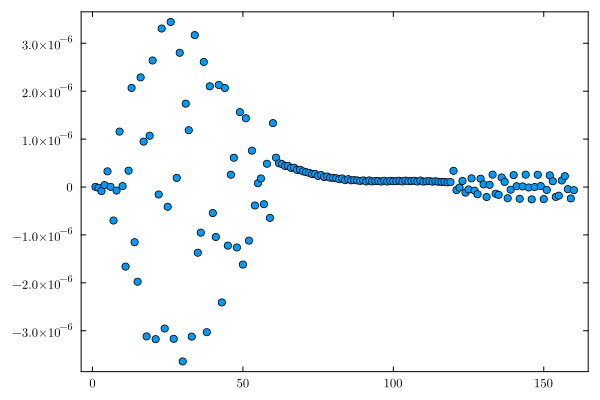

In [154]:
scatter(1:160, real([T1[60,j1] * j1 * T1[j1,120] for j1 in 1:160]))

In [168]:
wynn(accumulate(+, [T1[600,j1] * (j1 * ref_sl / 2) * T1[j1,1200] for j1 in 1:1600])[end-50:end], 1e-10)[1] / wynn(accumulate(+, [T1[600,j1] * T1[j1,1200] for j1 in 1:1600])[end-50:end], 1e-10)[1]

41.38876484739051 + 0.7792743096330148im

Refinement doesn't help either, the matrix multiplication results (i.e. without employing Wynn's algorithm for the $j$-summations) agree with those of the direct computation with Wynn.

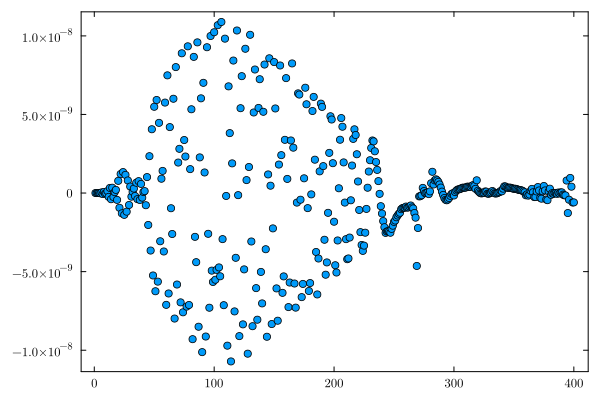

In [170]:
T1 = trans_mat_perfect(mu_test(0.5, 2.0), id, 200.0, γ, Λ, 2, kappa, 1e-10, 1.0, 0.01);
scatter(1:400, real([T1[300,j1] * j1 * T1[j1,360] for j1 in 1:400]))

The identity as measure?

In [177]:
T1 = trans_mat_perfect(id, id, 120.0, γ, Λ, 2, kappa, 1e-10, 0.5, 0.01);

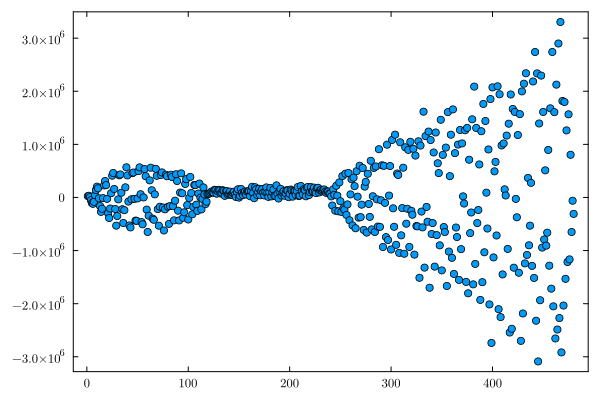

In [178]:
scatter(1:480, real([T1[120,j1] * j1 * T1[j1,240] for j1 in 1:480]))

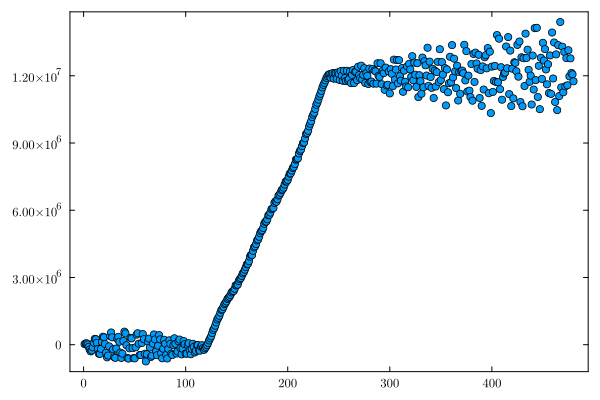

In [179]:
scatter(1:480, accumulate(+,real([T1[120,j1] * j1 * T1[j1,240] for j1 in 1:480])))

In [183]:
wynn(accumulate(+, [T1[120,j1] * (j1 * 0.5 / 2) * T1[j1,240] for j1 in 1:480])[end-50:end], 1e-10)[1] / wynn(accumulate(+, [T1[120,j1] * T1[j1,240] for j1 in 1:480])[end-50:end], 1e-10)[1]

38.57521633031145 - 0.3511341514361012im

# Scaling up the boundary

Check if the variance becomes smaller when scaling up the boundary. It seems that currently, strong fluctuations dominate, such that the stationary point contribution for $j$ does not contribute. If the $k$-summation within the transfer matrix leads to sharper peaking, the variance of $j$ could also become smaller.
If we know $\kappa$ for one pair $(j_0,j_1)$ then by the simple relation $\kappa(\lambda)=\beta\sqrt(\lambda)$, we can know all other $\kappa$ when scaling the boundary up as $(\lambda j_0, \lambda j_1)$.

## $V = 1$

In [46]:
V = 1
j0 = 1.0
j1 = 2.0
Λ = 0.1
γ = 1.0
T0 = log(sqrt(j1)/sqrt(j0)) * sqrt(3 / Λ)

kappa_0 = 0.7049400933982025
function kappa_from_lambda(lambda)
    """
    kappa_0 is for j0=1, j1=2
    """
    return kappa_0 * sqrt(lambda)
end



μ = mu_test(0.5, 2.0)

lambda = 1

evs = []
rel_vars = []
for lambda in 1:100
    kappa = kappa_from_lambda(lambda)
    k_sol = solve_eom_VS_VT(lambda * j0, lambda * j1, Λ, γ, V, kappa, 3.1)[2][1]

    ref_tl = 0.1 / lambda
    ref_sl = 1.0

    i0 = Int(2 * lambda * j0 / (γ * ref_sl))
    i1 = Int(2 * lambda * j1 / (γ * ref_sl))

    k_max = 50.0
    kvals = (0.5*ref_tl):(0.5*ref_tl):k_max

    amplitudes = [μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
    amplitudes_k = [trap(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
    amplitudes_k_sq = [trap_sq(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]

    ev_k = wynn(accumulate(+, amplitudes_k)[end - 50:end], 1e-10)[1] / wynn(accumulate(+, amplitudes)[end - 50:end], 1e-10)[1]
    push!(evs, ev_k)
    
    ev_k_sq = wynn(accumulate(+, amplitudes_k_sq)[end - 50:end], 1e-10)[1] / wynn(accumulate(+, amplitudes)[end - 50:end], 1e-10)[1]
    rel_var_k = sqrt(abs(real(ev_k_sq) - real(ev_k)^2) / real(ev_k))
    push!(rel_vars, rel_var_k)
end

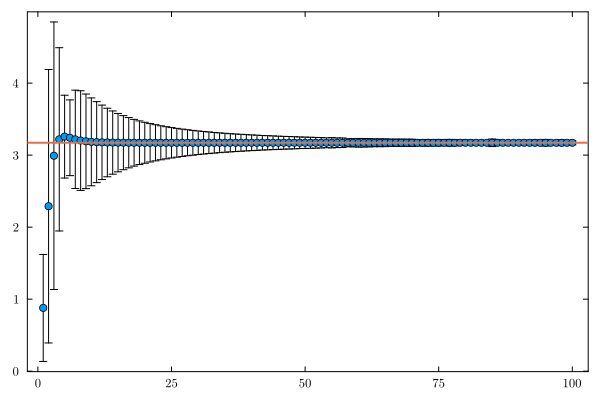

In [32]:
lambda = 1
k_sol = solve_eom_VS_VT(lambda * j0, lambda * j1, Λ, γ, V, kappa_0, 3.1)[2][1]
scatter(1:100, real(evs), yerror=real(evs .* rel_vars))
hline!([k_sol])

We see that when scaling up the boundary and, at the same time, refine the timelike spectrum, the fluctuations as measured by the relative variance go to zero, i.e. $\langle k\rangle$ becomes more sharply peaked around the classical solution. Importantly, since we tune $\kappa$ simultaneously with $\lambda$, the expectation values all give the same value, only their peaking changes.
What happens if we do not choose $\kappa$ for all the different entries but instead fix it from the outset, say for the transition $(50, 100)$?

In [47]:
V = 1
j0 = 1.0
j1 = 2.0
Λ = 0.1
γ = 1.0
T0 = log(sqrt(j1)/sqrt(j0)) * sqrt(3 / Λ)

kappa_0 = 0.7049400933982025
function kappa_from_lambda(lambda)
    """
    kappa_0 is for j0=1, j1=2
    """
    return kappa_0 * sqrt(lambda)
end

k_max = 100.0
kvals = (0.5*ref_tl):(0.5*ref_tl):k_max

μ = mu_test(0.0, 2.5)


peak_lambda = 25
kappa = kappa_from_lambda(peak_lambda)
k_sol = solve_eom_VS_VT(peak_lambda * j0, peak_lambda * j1, Λ, γ, V, kappa, 3.1)[2][1]
evs = []
rel_vars = []
for lambda in 1:100


    ref_tl = 0.1 / lambda
    ref_sl = 1.0

    i0 = Int(2 * lambda * j0 / (γ * ref_sl))
    i1 = Int(2 * lambda * j1 / (γ * ref_sl))
    amplitudes = [μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
    amplitudes_k = [trap(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
    amplitudes_k_sq = [trap_sq(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals]
    ev_k = wynn(accumulate(+, amplitudes_k)[end - 50:end], 1e-10)[1] / wynn(accumulate(+, amplitudes)[end - 50:end], 1e-10)[1]
    push!(evs, ev_k)
    ev_k_sq = wynn(accumulate(+, amplitudes_k_sq)[end - 50:end], 1e-10)[1] / wynn(accumulate(+, amplitudes)[end - 50:end], 1e-10)[1]
    rel_var_k = sqrt(abs(real(ev_k_sq) - real(ev_k)^2) / real(ev_k))
    push!(rel_vars, rel_var_k)
end

UndefVarError: UndefVarError: `ref_tl` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

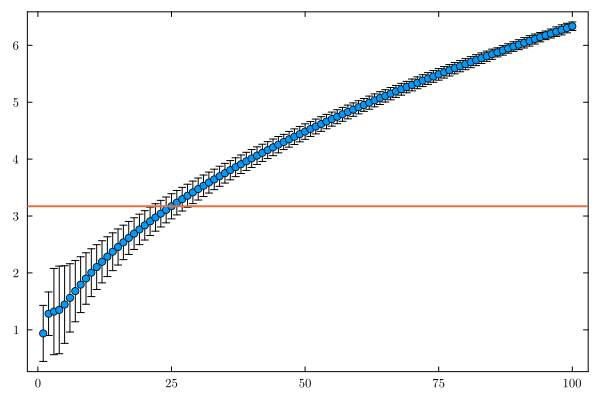

In [130]:
scatter(1:100, real(evs), yerror=real(evs .* rel_vars))
hline!([k_sol])

What this tells us is that if we fix $\lambda$ for a specific $(j_0,j_1)$ and we then start scaling up the boundary without adjusting $\lambda$, then only at boundary values $(j_0,j_1)$ we find the continuum result. The peaking is sharper as we increase the scaling of the boundary.

## $V=2$

## Classic action and solution

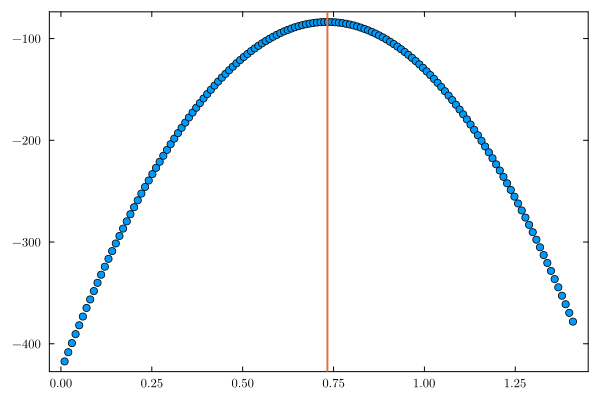

In [189]:
V = 2
Λ = 0.1
γ = 1.0
j0 = 25.0
j2 = 50.0

ref_sl = 1.0

a_max = 70.0
N = Int(ceil(2 * a_max / (γ * ref_sl)))

i0 = Int(ceil(2 * j0 / (γ * ref_sl)))
i2 = Int(ceil(2 * j2 / (γ * ref_sl)))

kappa = nlsolve(eom_for_scale(j0, j2, Λ), [2.5], xtol=1e-15, ftol=1e-15).zero[1]
j_sol, k_sol, H_sol, t_sol = solve_eom_VS_VT(j0, j2, Λ, γ, 2, 2 * kappa, 3.1716785823044)

Regge = [(kappa * V)^3 * (S_III(j0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k_sol[1], Λ) + S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, j2 / (kappa * V)^2, k_sol[2], Λ)) for  i1 in 1:N]
scatter([ref_sl * γ * 0.5 * i1 / (kappa * V)^2 for i1 in 1:N], real(Regge))
vline!([j_sol[2] / (kappa * V)^2])

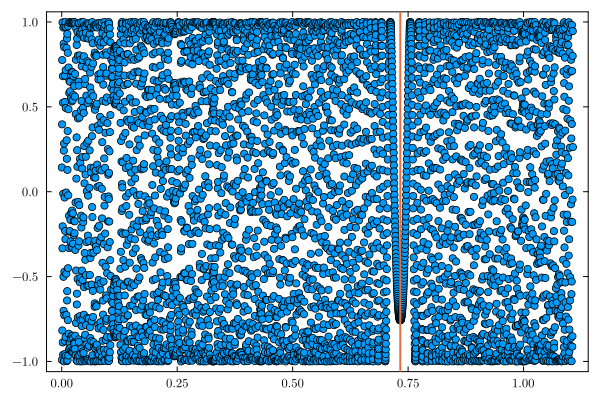

In [178]:
ref_sl = 0.1

a_max = 220.0
N = Int(ceil(2 * a_max / (γ * ref_sl)))

i0 = Int(ceil(2 * j0 / (γ * ref_sl)))
i2 = Int(ceil(2 * j2 / (γ * ref_sl)))

Regge_exp = [exp(im * (kappa * V)^3 * (S_III(j0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k_sol[1], Λ) + S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, j2 / (kappa * V)^2, k_sol[2], Λ))) for  i1 in 1:N]
scatter([ref_sl * γ * 0.5 * i1 / (kappa * V)^2 for i1 in 1:N], real(Regge_exp))
vline!([j_sol[2] / (kappa * V)^2])

We can clearly observe that for too coarse spectra, the stationary point can be hardly resolved.

In [98]:
function mu_test(a, b, c)
    return (j0, j1, k) -> (k * (j0 * j1)^c)   / (((j0 - j1)^2 + 8 * k^2)^(a) * ((j0 + j1)^2 + 8 * k^2)^(b))
end

mu_test (generic function with 2 methods)

In [179]:
k_max = 5.0
ref_tl = 0.1 / 50
kvals = (0.5*ref_tl):(0.5*ref_tl):k_max
μ = mu_test(0.0, 2.5, 2.0)

T_j0j1 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
T_j1j2 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N];

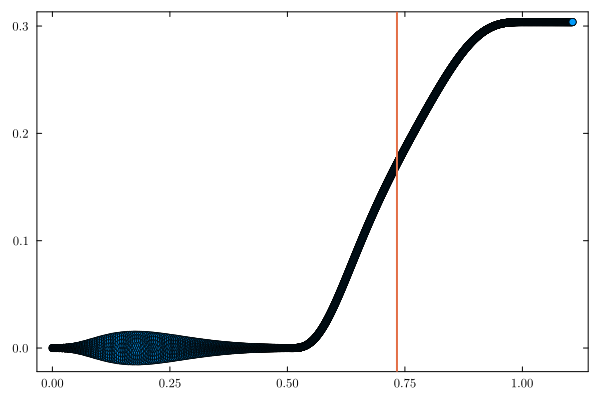

In [180]:
eff_amp = [T_j0j1[i1] * T_j1j2[i1] for i1 in 1:N]
scatter([ref_sl * γ * 0.5 * i1 / (kappa * V)^2 for i1 in 1:N], accumulate(+, real(eff_amp)))
vline!([j_sol[2] / (kappa * V)^2])

Evaluating the amplitude on the solutions for $k$.

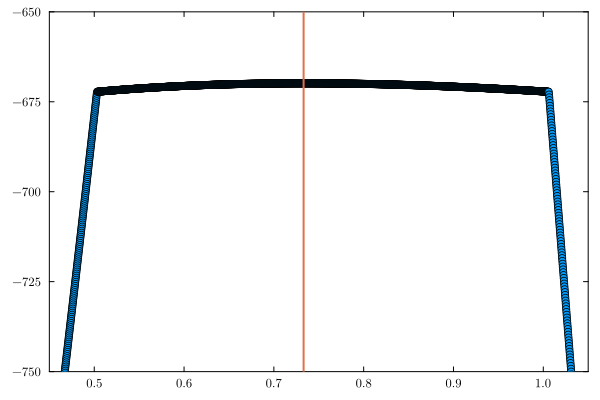

In [187]:
k0_sols = [nlsolve(eom_1slice(j0 / (2 * kappa)^2, ref_sl * γ * 0.5 * i1 / (2 * kappa )^2, Λ, γ), [2.7]).zero[1] for i1 in 1:N]
k1_sols = [nlsolve(eom_1slice(ref_sl * γ * 0.5 * i1 / (2 * kappa )^2, j2 / (2 * kappa)^2, Λ, γ), [1.5]).zero[1] for i1 in 1:N]
eff_Regge = [(kappa * V)^3 * (S_III(j0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k0_sols[i1], Λ) + S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, j2 / (kappa * V)^2, k1_sols[i1], Λ)) for  i1 in 1:N]
scatter([ref_sl * γ * 0.5 * i1 / (kappa * V)^2 for i1 in 1:N], real(eff_Regge), xlims=(0.45,1.05), ylims=(-750,-650))
vline!([j_sol[2] / (kappa * V)^2])

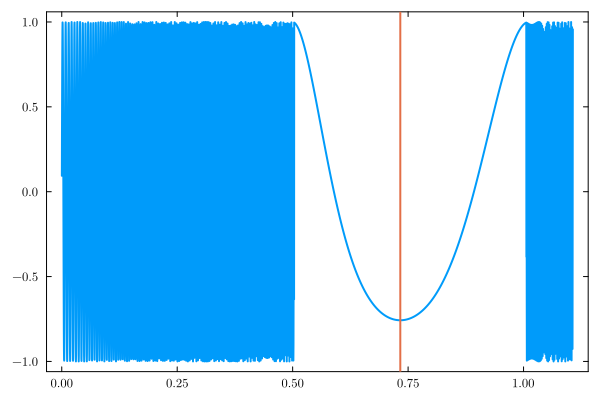

In [182]:
plot([ref_sl * γ * 0.5 * i1 / (kappa * V)^2 for i1 in 1:N], real(exp.( im .* eff_Regge)))
vline!([j_sol[2] / (kappa * V)^2])

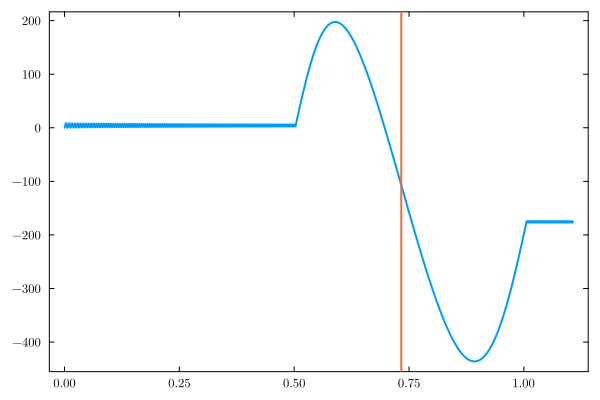

In [183]:
plot([ref_sl * γ * 0.5 * i1 / (kappa * V)^2 for i1 in 1:N], accumulate(+, real(exp.( im .* eff_Regge))))
vline!([j_sol[2] / (kappa * V)^2])

In [64]:
V = 2
Λ = 0.1
γ = 1.0
j0 = 1.0
j2 = 2.0

lambda = 1

ev_j = []
ev_k = []
rel_vars_j = []
rel_vars_k = []

Ts = []
for lambda in 1:5:31
    ref_tl = 0.1 / lambda
    ref_sl = 0.1

    k_max = 5.0
    kvals = (0.5*ref_tl):(0.5*ref_tl):k_max

    a_max = 120.0
    N = Int(ceil(2 * a_max / (γ * ref_sl)))

    i0 = Int(ceil(2 * lambda * j0 / (γ * ref_sl)))
    i2 = Int(ceil(2 * lambda * j2 / (γ * ref_sl)))

    kappa = kappa_from_lambda(lambda)

    μ = mu_test(0.5, 2.0)

    T_j0j1 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    T_j1j2 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    push!(Ts, T_j0j1)
    push!(Ts, T_j1j2)

    Z = dot(T_j0j1, T_j1j2)

    jmat = zeros(Float64, N, N)
    for i1 in 1:N
        jmat[i1,i1] = 0.5 * γ * ref_sl * i1 / (kappa * V)^2
    end

    jmat_sq = zeros(Float64, N, N)
    for i1 in 1:N
        jmat[i1,i1] = (0.5 * γ * ref_sl * i1 / (kappa * V)^2)^2
    end

    j_eval = dot(T_j0j1, jmat * T_j1j2) / Z
    push!(ev_j, j_eval)

    j_sq_eval = dot(T_j0j1, jmat_sq * T_j1j2) / Z
    rel_var_j = sqrt(abs(real(j_sq_eval) - (real(j_eval))^2)) / real(j_eval)
    push!(rel_vars_j, rel_var_j)


    Tk_j0j1 = [wynn(accumulate(+, [trap(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    Tk_j1j2 = [wynn(accumulate(+, [trap(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

    k_evals = [dot(Tk_j0j1, T_j1j2) / Z, dot(T_j0j1, Tk_j1j2) / Z]
    push!(ev_k, k_evals)

    Tk_sq_j0j1 = [wynn(accumulate(+, [trap_sq(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    Tk_sq_j1j2 = [wynn(accumulate(+, [trap_sq(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

    k_sq_evals = [dot(Tk_sq_j0j1, T_j1j2) / Z, dot(T_j0j1, Tk_sq_j1j2) / Z]

    rel_var_k = [sqrt(abs(real(k_sq_evals[1]) - real(k_evals[1])^2)) / real(k_evals[1]), sqrt(abs(real(k_sq_evals[1]) - real(k_evals[1])^2)) / real(k_evals[1])]
    push!(rel_vars_k, rel_var_k)
end

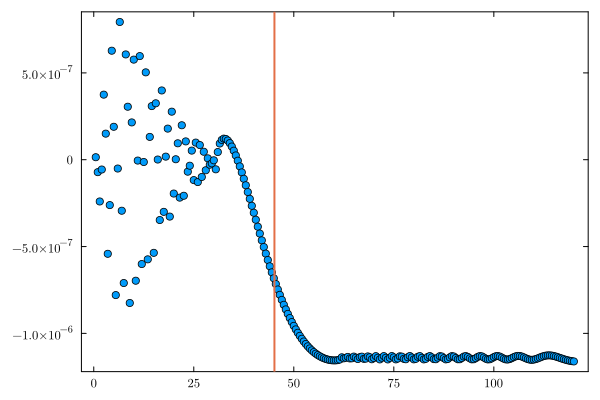

In [58]:
scatter(0.5:0.5:120, real(accumulate(+, Ts[13] .* Ts[14])))
vline!([45.16])

In [59]:
lambda=31
kappa = kappa_from_lambda(lambda)
j_sol, k_sol = solve_eom_VS_VT(lambda * j0, lambda * j2, Λ, γ, V, kappa * V, 3.1)[1:2]

([31.0, 45.17488394558429, 62.0], [0.8012984186776926, 0.8018449265297612])

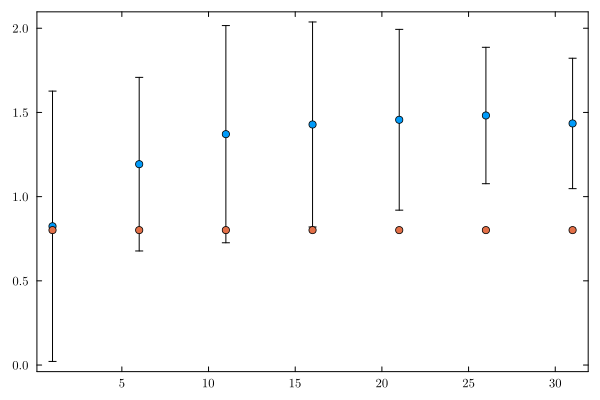

In [65]:
k0_sol = [solve_eom_VS_VT(l * j0, l * j2, Λ, γ, V, kappa_from_lambda(l) * V, 3.1)[2][1] for l in 1:5:31]
scatter(1:5:31, real([ev_k[l][1] for l in 1:7]), yerror=[real(ev_k[l][1]) * real(rel_vars_k[l][1]) for l in 1:7])
scatter!(1:5:31, k0_sol)

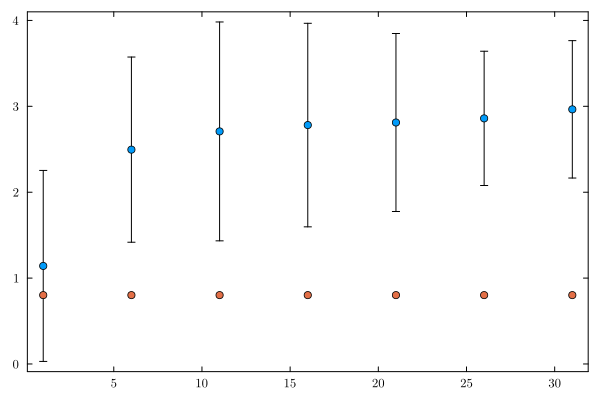

In [66]:
k1_sol = [solve_eom_VS_VT(l * j0, l * j2, Λ, γ, V, kappa_from_lambda(l) * V, 3.1)[2][2] for l in 1:5:7]
scatter(1:5:31, real([ev_k[l][2] for l in 1:7]), yerror=[real(ev_k[l][2]) * real(rel_vars_k[l][2]) for l in 1:7])
scatter!(1:5:31, k1_sol)

In [69]:
ev_j[5]

0.07474293627801715 + 0.04226257794199351im

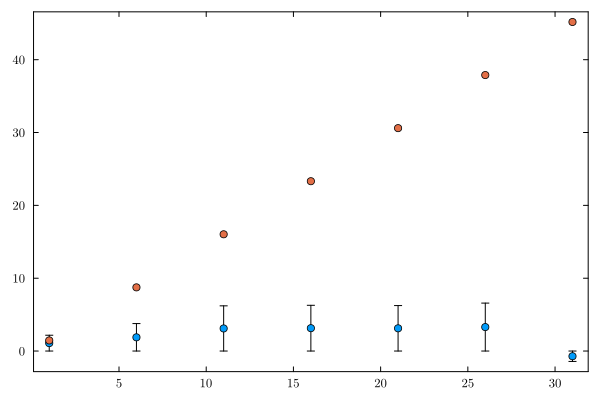

In [71]:
j_sol = [solve_eom_VS_VT(lambda * j0, lambda * j2, Λ, γ, V, kappa_from_lambda(lambda) * V, 3.1)[1][2] for lambda in 1:5:31]

scatter(1:5:31, real([ (kappa_from_lambda(lambda) * V)^2 * ev_j[l] for (l,lambda) in enumerate(1:5:31)]), yerror=[(kappa_from_lambda(lambda) * V)^2 * real(ev_j[l]) * real(rel_vars_j[l]) for (l,lambda) in enumerate(1:5:31)])
scatter!(1:5:31, [solve_eom_VS_VT(l * j0, l * j2, Λ, γ, V, kappa_from_lambda(l) * V, 3.1)[1][2] for l in 1:5:31])

In [158]:
V = 2
Λ = 0.1
γ = 1.0
j0 = 1.0
j2 = 2.0

lambda = 1

ev_j = []
ev_k = []
rel_vars_j = []
rel_vars_k = []

lambda = 50
ref_tl = 0.1 / lambda
ref_sl = 0.05

k_max = 5.0
kvals = (0.5*ref_tl):(0.5*ref_tl):k_max

a_max = 120.0
N = Int(ceil(2 * a_max / (γ * ref_sl)))

i0 = Int(ceil(2 * lambda * j0 / (γ * ref_sl)))
i2 = Int(ceil(2 * lambda * j2 / (γ * ref_sl)))

kappa = kappa_from_lambda(lambda)

μ = mu_test(0.5, 2.0)

T_j0j1 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
T_j1j2 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

Z = dot(T_j0j1, T_j1j2)

jmat = zeros(Float64, N, N)
for i1 in 1:N
    jmat[i1,i1] = 0.5 * γ * ref_sl * i1 / (kappa * V)^2
end

jmat_sq = zeros(Float64, N, N)
for i1 in 1:N
    jmat[i1,i1] = (0.5 * γ * ref_sl * i1 / (kappa * V)^2)^2
end

j_eval = dot(T_j0j1, jmat * T_j1j2) / Z

j_sq_eval = dot(T_j0j1, jmat_sq * T_j1j2) / Z
rel_var_j = sqrt(abs(real(j_sq_eval) - (real(j_eval))^2)) / real(j_eval)


Tk_j0j1 = [wynn(accumulate(+, [trap(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
Tk_j1j2 = [wynn(accumulate(+, [trap(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

k_evals = [dot(Tk_j0j1, T_j1j2) / Z, dot(T_j0j1, Tk_j1j2) / Z]

Tk_sq_j0j1 = [wynn(accumulate(+, [trap_sq(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
Tk_sq_j1j2 = [wynn(accumulate(+, [trap_sq(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

k_sq_evals = [dot(Tk_sq_j0j1, T_j1j2) / Z, dot(T_j0j1, Tk_sq_j1j2) / Z]

rel_var_k = [sqrt(abs(real(k_sq_evals[1]) - real(k_evals[1])^2)) / real(k_evals[1]), sqrt(abs(real(k_sq_evals[1]) - real(k_evals[1])^2)) / real(k_evals[1])]

(kappa_from_lambda(50) * 2)^2 * j_eval

18.074036441918924 + 16.322391242707937im

In [156]:
(kappa_from_lambda(50) * 2)^2 * j_eval

18.506224128177138 + 17.06127206092912im

In [151]:
16 * (kappa_from_lambda(16) * 2)^2 *  ev_j[4] / 2

25.633411853816664 + 8.875502739639337im

In [114]:
V = 2
Λ = 0.1
γ = 1.0
j0 = 1.0
j2 = 2.0
kappa nlsolve(eom_for_scale(j0, j2, Λ), [0.7049400933982025]).zero[1]

0.7049400933982025

In [ ]:
V = 2
Λ = 0.1
γ = 1.0
j0 = 1.0
j2 = 2.0

lambda = 1
0.7049400933982025

kappa = nlsolve(eom_for_scale(j0, j1, Λ), [0.7049400933982025]).zero[1]

ev_j = []
ev_k = []
rel_vars_j = []
rel_vars_k = []

Ts = []
for lambda in 1:5:31
    ref_tl = 0.05 / lambda
    ref_sl = 1.0

    k_max = 5.0
    kvals = (0.5*ref_tl):(0.5*ref_tl):k_max

    a_max = 120.0
    N = Int(ceil(2 * a_max / (γ * ref_sl)))

    i0 = Int(ceil(2 * lambda * j0 / (γ * ref_sl)))
    i2 = Int(ceil(2 * lambda * j2 / (γ * ref_sl)))

    kappa = kappa_from_lambda(lambda)

    μ = mu_test(0.5, 2.0)

    T_j0j1 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    T_j1j2 = [wynn(accumulate(+, [μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    push!(Ts, T_j0j1)
    push!(Ts, T_j1j2)

    Z = dot(T_j0j1, T_j1j2)

    jmat = zeros(Float64, N, N)
    for i1 in 1:N
        jmat[i1,i1] = 0.5 * γ * ref_sl * i1 / (kappa * V)^2
    end

    jmat_sq = zeros(Float64, N, N)
    for i1 in 1:N
        jmat[i1,i1] = (0.5 * γ * ref_sl * i1 / (kappa * V)^2)^2
    end

    j_eval = dot(T_j0j1, jmat * T_j1j2) / Z
    push!(ev_j, j_eval)

    j_sq_eval = dot(T_j0j1, jmat_sq * T_j1j2) / Z
    rel_var_j = sqrt(abs(real(j_sq_eval) - (real(j_eval))^2)) / real(j_eval)
    push!(rel_vars_j, rel_var_j)


    Tk_j0j1 = [wynn(accumulate(+, [trap(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    Tk_j1j2 = [wynn(accumulate(+, [trap(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

    k_evals = [dot(Tk_j0j1, T_j1j2) / Z, dot(T_j0j1, Tk_j1j2) / Z]
    push!(ev_k, k_evals)

    Tk_sq_j0j1 = [wynn(accumulate(+, [trap_sq(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i0, ref_sl * γ * 0.5 * i1, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i0 / (kappa * V)^2, ref_sl * γ * 0.5 * i1 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]
    Tk_sq_j1j2 = [wynn(accumulate(+, [trap_sq(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k) * μ(ref_sl * γ * 0.5 * i1, ref_sl * γ * 0.5 * i2, k) *  exp((kappa * V)^3 * im * S_III(ref_sl * γ * 0.5 * i1 / (kappa * V)^2, ref_sl * γ * 0.5 * i2 / (kappa * V)^2, k, Λ)) for k in kvals])[end-50:end], 1e-10)[1] for i1 in 1:N]

    k_sq_evals = [dot(Tk_sq_j0j1, T_j1j2) / Z, dot(T_j0j1, Tk_sq_j1j2) / Z]

    rel_var_k = [sqrt(abs(real(k_sq_evals[1]) - real(k_evals[1])^2)) / real(k_evals[1]), sqrt(abs(real(k_sq_evals[1]) - real(k_evals[1])^2)) / real(k_evals[1])]
    push!(rel_vars_k, rel_var_k)